# 🔍 Fraud Detection — Deep Learning Pipeline (TensorFlow/Keras)
**UAS Assignment — Machine Learning Class**

| | |
|---|---|
| **Nama** | `Mohammad Fauzi Hadiwijaya` |
| **NIM** | `101032300044` |
| **Kelas** | `TK-47-04` |

---
## Pipeline Overview
1. Setup & Install Libraries
2. Load Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing & Feature Engineering
5. Handle Class Imbalance
6. MLflow Setup
7. Baseline Deep Learning Model (Simple MLP)
8. Improved Deep Learning Model (Deep MLP)
9. Hyperparameter Tuning dengan Optuna
10. Evaluasi & Perbandingan Model
11. MLflow Tracking Summary

## 1. Setup & Install Libraries

In [2]:
!pip install optuna mlflow imbalanced-learn --quiet
print('✅ Libraries installed!')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 654.6 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# TensorFlow
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Evaluation
from sklearn.metrics import (
    roc_auc_score, f1_score, accuracy_score,
    precision_score, recall_score,
    confusion_matrix, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)

# Optuna & MLflow
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import mlflow
import mlflow.tensorflow

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ All libraries imported!')
print(f'   TensorFlow : {tf.__version__}')
print(f'   Optuna     : {optuna.__version__}')
print(f'   MLflow     : {mlflow.__version__}')

✅ All libraries imported!
   TensorFlow : 2.20.0
   Optuna     : 4.9.0
   MLflow     : 3.14.0


## 2. Load Dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
TRAIN_PATH = '/content/drive/MyDrive/midterm-m1/train_transaction.csv'
TEST_PATH  = '/content/drive/MyDrive/midterm-m1/test_transaction.csv'

print('📂 Loading dataset...')
train = pd.read_csv(TRAIN_PATH, nrows=100000)
test  = pd.read_csv(TEST_PATH,  nrows=50000)

print(f'✅ Train shape : {train.shape}')
print(f'✅ Test shape  : {test.shape}')

📂 Loading dataset...
✅ Train shape : (100000, 394)
✅ Test shape  : (50000, 393)


## 3. Exploratory Data Analysis (EDA)

=== Distribusi Target (isFraud) ===
         Count  Percentage (%)
isFraud                       
0        97439           97.44
1         2561            2.56


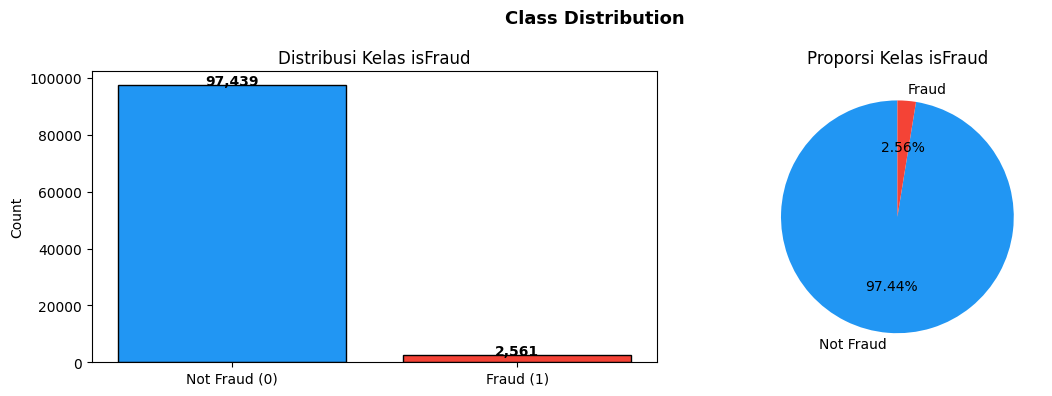

In [6]:
fraud_counts = train['isFraud'].value_counts()
fraud_pct    = train['isFraud'].value_counts(normalize=True) * 100

print('=== Distribusi Target (isFraud) ===')
print(pd.DataFrame({'Count': fraud_counts, 'Percentage (%)': fraud_pct.round(2)}))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['Not Fraud (0)', 'Fraud (1)'], fraud_counts.values,
            color=['#2196F3', '#F44336'], edgecolor='black')
axes[0].set_title('Distribusi Kelas isFraud')
axes[0].set_ylabel('Count')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(fraud_counts.values, labels=['Not Fraud', 'Fraud'],
            autopct='%1.2f%%', colors=['#2196F3', '#F44336'], startangle=90)
axes[1].set_title('Proporsi Kelas isFraud')
plt.suptitle('Class Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Dataset sangat imbalanced — hanya sekitar 2.56% transaksi yang berlabel fraud. Hal ini menjadi alasan utama digunakannya SMOTE pada tahap preprocessing, karena tanpa penyeimbangan kelas, model cenderung bias memprediksi "Not Fraud" untuk hampir semua data.

Kolom dengan missing values: 317 dari 394


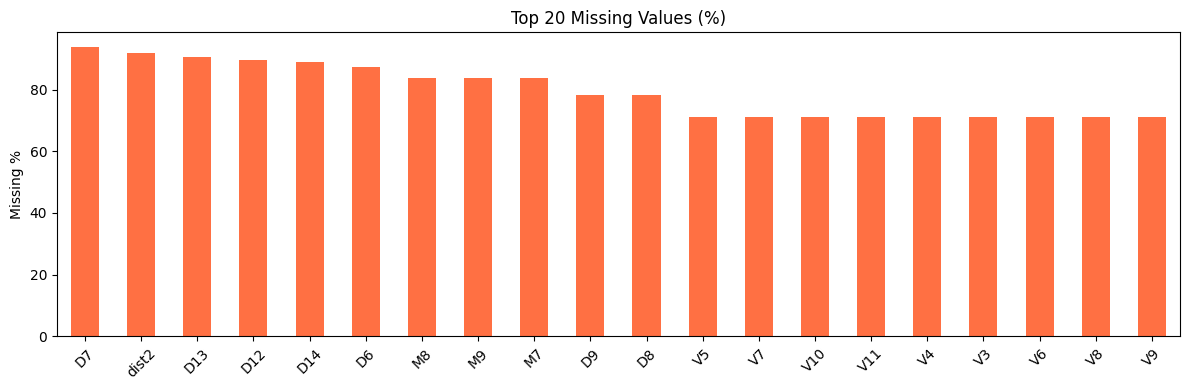

In [7]:
missing_pct = (train.isnull().mean() * 100).round(2)
missing_df  = missing_pct[missing_pct > 0].sort_values(ascending=False)
print(f'Kolom dengan missing values: {len(missing_df)} dari {train.shape[1]}')

plt.figure(figsize=(12, 4))
missing_df.head(20).plot(kind='bar', color='#FF7043')
plt.title('Top 20 Missing Values (%)')
plt.ylabel('Missing %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Insight**: Beberapa kolom memiliki missing value rate tinggi (>50%), umumnya berasal dari fitur identity yang memang opsional saat transaksi dilakukan. Kolom dengan missing >80% di-drop, sisanya diimputasi menggunakan median agar tidak mengubah distribusi data secara signifikan.

## 4. Data Preprocessing & Feature Engineering

In [8]:
y        = train['isFraud'].copy()
test_ids = test['TransactionID'].copy()
train_df = train.drop(columns=['isFraud'])
combined = pd.concat([train_df, test], axis=0, ignore_index=True)
n_train  = len(train_df)

# Drop kolom missing > 80%
drop_cols = combined.columns[combined.isnull().mean() > 0.8].tolist()
combined.drop(columns=drop_cols, inplace=True)
print(f'Kolom di-drop: {len(drop_cols)} | Shape: {combined.shape}')

# Feature Engineering
combined['TransactionAmt_log']   = np.log1p(combined['TransactionAmt'])
combined['Transaction_hour']     = (combined['TransactionDT'] / 3600).astype(int) % 24
combined['Transaction_day']      = (combined['TransactionDT'] / (3600*24)).astype(int) % 7

# Label Encoding
id_cols  = ['TransactionID', 'TransactionDT']
cat_cols = [c for c in combined.select_dtypes(include='object').columns if c not in id_cols]
le = LabelEncoder()
for col in cat_cols:
    combined[col] = le.fit_transform(combined[col].astype(str))

# Imputasi
feature_cols = [c for c in combined.columns if c not in id_cols]
imputer = SimpleImputer(strategy='median')
combined[feature_cols] = imputer.fit_transform(combined[feature_cols])

# Scaling (penting untuk DL)
scaler = StandardScaler()
combined[feature_cols] = scaler.fit_transform(combined[feature_cols])

X            = combined.iloc[:n_train][feature_cols].values
X_test_final = combined.iloc[n_train:][feature_cols].values

print(f'✅ Preprocessing selesai')
print(f'   X shape: {X.shape}')

Kolom di-drop: 8 | Shape: (150000, 385)
✅ Preprocessing selesai
   X shape: (100000, 386)


## 5. Handle Class Imbalance

In [9]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print('Applying SMOTE...')
smote = SMOTE(random_state=SEED, sampling_strategy=0.2)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Sebelum SMOTE : {dict(pd.Series(y_train).value_counts())}')
print(f'Sesudah SMOTE : {dict(pd.Series(y_train_sm).value_counts())}')

# Hitung class weight untuk DL
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
class_weight = {0: 1.0, 1: neg/pos}
print(f'\nClass weight: {class_weight}')

INPUT_DIM = X_train_sm.shape[1]
print(f'Input dimension: {INPUT_DIM}')

Applying SMOTE...
Sebelum SMOTE : {0: np.int64(77951), 1: np.int64(2049)}
Sesudah SMOTE : {0: np.int64(77951), 1: np.int64(15590)}

Class weight: {0: 1.0, 1: np.float64(38.043435822352365)}
Input dimension: 386


## 6. MLflow Setup

In [10]:
EXPERIMENT_NAME = 'fraud-detection-dl'
mlflow.set_experiment(EXPERIMENT_NAME)
print(f'✅ MLflow experiment: "{EXPERIMENT_NAME}"')

results = {}

def evaluate_dl_model(run_name, model, params, X_v, y_v):
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params(params)
        y_pred_prob = model.predict(X_v, verbose=0).flatten()
        y_pred      = (y_pred_prob >= 0.5).astype(int)

        auc  = roc_auc_score(y_v, y_pred_prob)
        f1   = f1_score(y_v, y_pred)
        acc  = accuracy_score(y_v, y_pred)
        prec = precision_score(y_v, y_pred)
        rec  = recall_score(y_v, y_pred)

        mlflow.log_metrics({'auc_roc': auc, 'f1_score': f1,
                            'accuracy': acc, 'precision': prec, 'recall': rec})
        run_id = mlflow.active_run().info.run_id

    results[run_name] = {
        'AUC-ROC': auc, 'F1-Score': f1, 'Accuracy': acc,
        'Precision': prec, 'Recall': rec,
        'model': model, 'run_id': run_id
    }

    print(f'\n===== {run_name} =====')
    print(f'  AUC-ROC   : {auc:.4f}')
    print(f'  F1-Score  : {f1:.4f}')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    return model

# Early stopping callback
early_stop = callbacks.EarlyStopping(
    monitor='val_auc', patience=5, restore_best_weights=True, mode='max'
)
print('✅ Helper & callbacks siap')

2026/06/19 07:07:04 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/06/19 07:07:04 INFO mlflow.store.db.utils: Updating database tables
2026/06/19 07:07:07 INFO mlflow.tracking.fluent: Experiment with name 'fraud-detection-dl' does not exist. Creating a new experiment.


✅ MLflow experiment: "fraud-detection-dl"
✅ Helper & callbacks siap


## 7. Baseline Deep Learning Model (Simple MLP)

**MLP (Multi-Layer Perceptron)** adalah arsitektur neural network paling dasar — terdiri dari input layer, beberapa hidden layers, dan output layer.

In [11]:
def build_simple_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
    )
    return model

print('Training Simple MLP (baseline)...')
simple_mlp = build_simple_mlp(INPUT_DIM)
simple_mlp.summary()

history_simple = simple_mlp.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

simple_params = {'layers': 2, 'units': '64-32', 'dropout': '0.3-0.2',
                 'lr': 0.001, 'batch_size': 512, 'epochs': 30}
evaluate_dl_model('Simple_MLP', simple_mlp, simple_params, X_val, y_val)
print('✅ Simple MLP selesai')

Training Simple MLP (baseline)...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        24,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,881 (105.00 KB)

 Trainable params: 26,881 (105.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.3370 - auc: 0.7873 - loss: 2.4313 - val_accuracy: 0.1635 - val_auc: 0.8454 - val_loss: 1.5099
Epoch 2/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.3664 - auc: 0.8569 - loss: 1.8821 - val_accuracy: 0.2614 - val_auc: 0.8586 - val_loss: 1.3582
Epoch 3/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.4243 - auc: 0.8837 - loss: 1.7246 - val_accuracy: 0.3144 - val_auc: 0.8591 - val_loss: 1.2587
Epoch 4/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.4796 - auc: 0.8989 - loss: 1.6147 - val_accuracy: 0.3586 - val_auc: 0.8634 - val_loss: 1.2171
Epoch 5/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5250 - auc: 0.9102 - loss: 1.5244 - val_accuracy: 0.4132 - val_auc: 0.8647 - val_loss: 1.1418
Epoch 6/30
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5637 - auc: 0.9201 - loss: 1.4370 - val_accuracy: 0.4570 - val_auc: 0.8651 - val_loss: 1.0681
Epoch 7/30
183/183 ━━━━━━━━━━━━━━━━━━

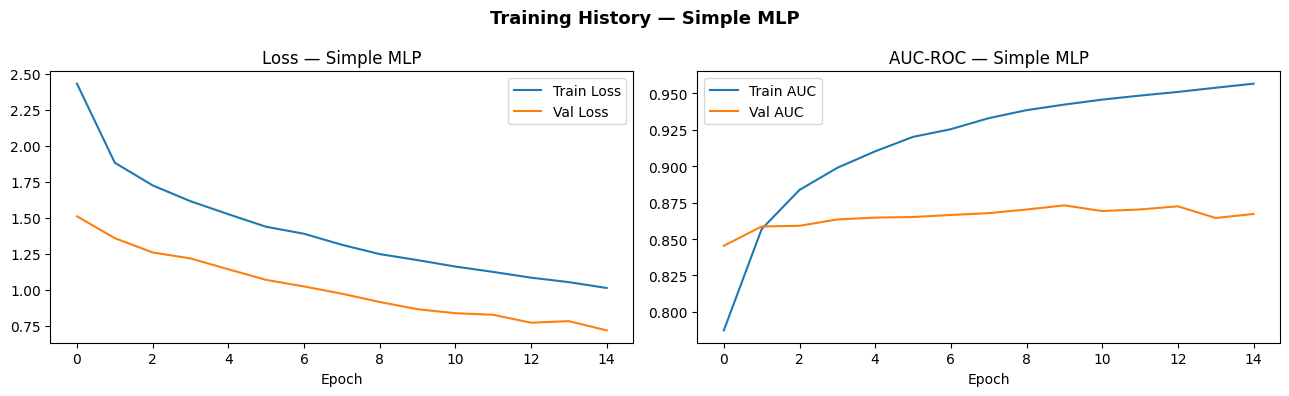

In [12]:
# Plot training history Simple MLP
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_simple.history['loss'], label='Train Loss')
axes[0].plot(history_simple.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss — Simple MLP')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_simple.history['auc'], label='Train AUC')
axes[1].plot(history_simple.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC-ROC — Simple MLP')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Training History — Simple MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Grafik training menunjukkan loss menurun dan AUC meningkat secara konsisten pada beberapa epoch awal, lalu mulai stabil/plateau. Early stopping otomatis menghentikan training saat `val_auc` tidak lagi membaik, sehingga model tidak overfitting ke data training.

## 8. Improved Deep Learning Model (Deep MLP)

Model lebih dalam dengan **Batch Normalization** untuk stabilisasi training dan **Dropout** yang lebih terstruktur.

In [13]:
def build_deep_mlp(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.1),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc'), 'accuracy']
    )
    return model

print('Training Deep MLP...')
deep_mlp = build_deep_mlp(INPUT_DIM)
deep_mlp.summary()

history_deep = deep_mlp.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=512,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

deep_params = {'layers': 4, 'units': '256-128-64-32',
               'dropout': '0.4-0.3-0.2-0.1', 'batch_norm': True,
               'lr': 0.001, 'batch_size': 512, 'epochs': 50}
evaluate_dl_model('Deep_MLP', deep_mlp, deep_params, X_val, y_val)
print('✅ Deep MLP selesai')

Training Deep MLP...


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 256)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 144,129 (563.00 KB)

 Trainable params: 143,233 (559.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.5086 - auc: 0.7832 - loss: 2.8781 - val_accuracy: 0.1988 - val_auc: 0.8425 - val_loss: 1.5187
Epoch 2/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.4417 - auc: 0.8659 - loss: 1.8235 - val_accuracy: 0.2808 - val_auc: 0.8544 - val_loss: 1.4284
Epoch 3/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - accuracy: 0.5037 - auc: 0.8937 - loss: 1.6365 - val_accuracy: 0.3508 - val_auc: 0.8601 - val_loss: 1.3140
Epoch 4/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - accuracy: 0.5506 - auc: 0.9113 - loss: 1.4865 - val_accuracy: 0.4530 - val_auc: 0.8646 - val_loss: 1.1681
Epoch 5/50
183/183 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5885 - auc: 0.9237 - loss: 1.3850 - val_accuracy: 0.4826 - val_auc: 0.8598 - val_loss: 1.0467

===== Deep_MLP =====
  AUC-ROC   : 0.8429
  F1-Score  : 0.0592
  Accuracy  : 0.1988
  Precision : 0.0305
  Recall    : 0.9844
✅ Deep MLP selesai


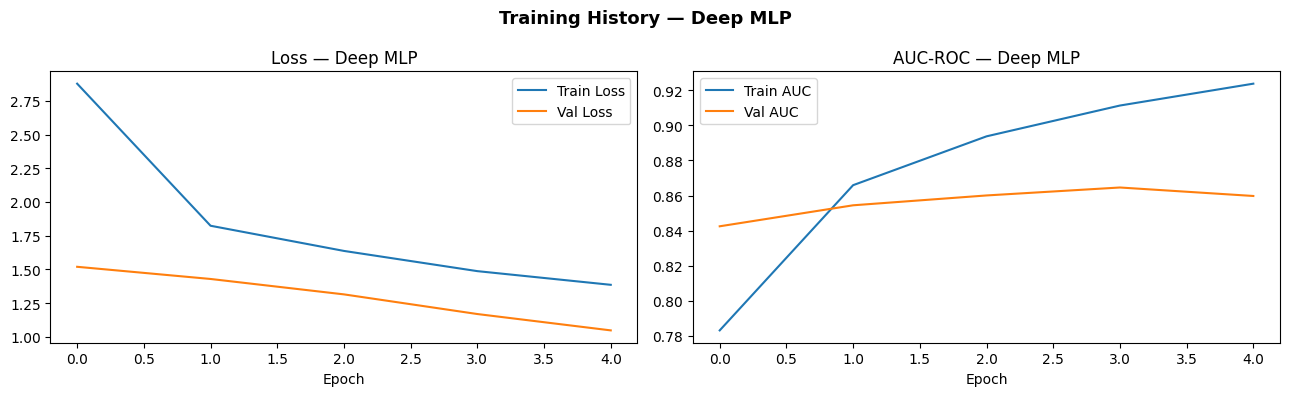

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history_deep.history['loss'], label='Train Loss')
axes[0].plot(history_deep.history['val_loss'], label='Val Loss')
axes[0].set_title('Loss — Deep MLP')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_deep.history['auc'], label='Train AUC')
axes[1].plot(history_deep.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC-ROC — Deep MLP')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Training History — Deep MLP', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: Grafik training menunjukkan loss menurun dan AUC meningkat secara konsisten pada beberapa epoch awal, lalu mulai stabil/plateau. Early stopping otomatis menghentikan training saat `val_auc` tidak lagi membaik, sehingga model tidak overfitting ke data training.

## 9. Hyperparameter Tuning dengan Optuna

Optuna akan mencari kombinasi terbaik: jumlah layer, jumlah units, dropout rate, dan learning rate.

In [15]:
def build_optuna_mlp(trial, input_dim):
    n_layers = trial.suggest_int('n_layers', 2, 4)
    lr       = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    model    = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))

    for i in range(n_layers):
        units   = trial.suggest_categorical(f'units_{i}', [64, 128, 256])
        dropout = trial.suggest_float(f'dropout_{i}', 0.1, 0.5)
        model.add(layers.Dense(units, activation='relu'))
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))

    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    return model

def objective(trial):
    model = build_optuna_mlp(trial, INPUT_DIM)
    batch_size = trial.suggest_categorical('batch_size', [256, 512, 1024])
    es = callbacks.EarlyStopping(monitor='val_auc', patience=3,
                                  restore_best_weights=True, mode='max')
    history = model.fit(
        X_train_sm, y_train_sm,
        validation_data=(X_val, y_val),
        epochs=20, batch_size=batch_size,
        class_weight=class_weight,
        callbacks=[es], verbose=0
    )
    return max(history.history['val_auc'])

print('🔍 Optuna tuning DL Model (15 trials)...')
study = optuna.create_study(direction='maximize', study_name='DL_fraud')
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f'\n✅ Best AUC-ROC (val): {study.best_value:.4f}')
print(f'Best params: {study.best_params}')

🔍 Optuna tuning DL Model (15 trials)...


  0%|          | 0/15 [00:00<?, ?it/s]


✅ Best AUC-ROC (val): 0.8791
Best params: {'n_layers': 2, 'lr': 0.0005225811320394639, 'units_0': 256, 'dropout_0': 0.49721854967597223, 'units_1': 128, 'dropout_1': 0.29886325067995234, 'batch_size': 1024}


In [16]:
# Train model terbaik dari Optuna
print('Training best Optuna model...')
best_model_optuna = build_optuna_mlp(
    optuna.trial.FixedTrial(study.best_params), INPUT_DIM
)
history_optuna = best_model_optuna.fit(
    X_train_sm, y_train_sm,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=study.best_params.get('batch_size', 512),
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

evaluate_dl_model('Optuna_MLP', best_model_optuna, study.best_params, X_val, y_val)
print('✅ Optuna MLP selesai')

Training best Optuna model...
Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - auc: 0.8014 - loss: 3.0226 - val_auc: 0.8409 - val_loss: 1.0276
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - auc: 0.8562 - loss: 2.0560 - val_auc: 0.8559 - val_loss: 1.1938
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - auc: 0.8766 - loss: 1.8007 - val_auc: 0.8590 - val_loss: 1.3092
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - auc: 0.8928 - loss: 1.6524 - val_auc: 0.8648 - val_loss: 1.3321
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - auc: 0.9021 - loss: 1.5946 - val_auc: 0.8639 - val_loss: 1.2746

===== Optuna_MLP =====
  AUC-ROC   : 0.8409
  F1-Score  : 0.0720
  Accuracy  : 0.3758
  Precision : 0.0374
  Recall    : 0.9453
✅ Optuna MLP selesai


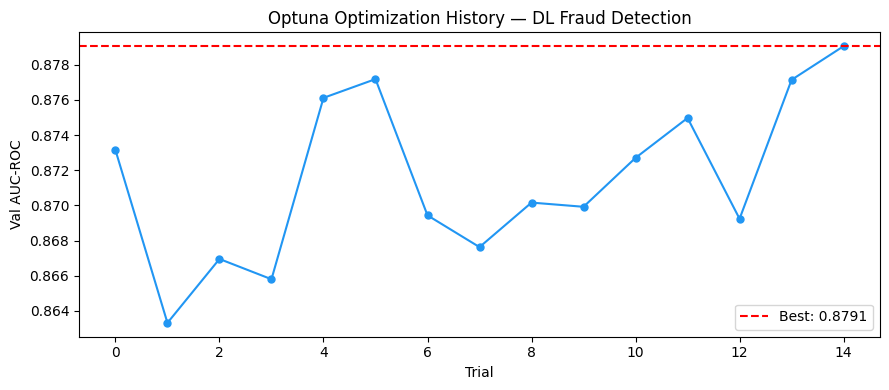

In [17]:
# Optuna optimization history
trial_vals = [t.value for t in study.trials if t.value is not None]
plt.figure(figsize=(9, 4))
plt.plot(trial_vals, marker='o', color='#2196F3', linewidth=1.5, markersize=5)
plt.axhline(study.best_value, color='red', linestyle='--',
            label=f'Best: {study.best_value:.4f}')
plt.title('Optuna Optimization History — DL Fraud Detection')
plt.xlabel('Trial')
plt.ylabel('Val AUC-ROC')
plt.legend()
plt.tight_layout()
plt.show()

**Insight**: Grafik menunjukkan pencarian hyperparameter melalui 15 trial percobaan. Garis merah putus-putus menandakan AUC validasi terbaik yang ditemukan Optuna. Variasi antar trial menunjukkan bahwa kombinasi hyperparameter (jumlah layer, neuron, dropout, learning rate) cukup berpengaruh terhadap performa model.

## 10. Evaluasi & Perbandingan Model

In [18]:
from sklearn.metrics import precision_recall_curve

def find_best_threshold(y_true, y_pred_prob):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_pred_prob)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-9)
    best_idx = np.argmax(f1_scores)
    return thresholds[best_idx], f1_scores[best_idx]

# Cari threshold terbaik untuk tiap model & update F1-Score
for name, m in results.items():
    y_pred_prob = m['model'].predict(X_val, verbose=0).flatten()
    best_thresh, best_f1 = find_best_threshold(y_val, y_pred_prob)

    y_pred_new = (y_pred_prob >= best_thresh).astype(int)
    results[name]['F1-Score']  = f1_score(y_val, y_pred_new)
    results[name]['Precision'] = precision_score(y_val, y_pred_new)
    results[name]['Recall']    = recall_score(y_val, y_pred_new)
    results[name]['Best_Threshold'] = best_thresh

    print(f'{name}: threshold optimal = {best_thresh:.3f} → F1-Score baru = {results[name]["F1-Score"]:.4f}')

Simple_MLP: threshold optimal = 0.996 → F1-Score baru = 0.4543
Deep_MLP: threshold optimal = 0.987 → F1-Score baru = 0.3349
Optuna_MLP: threshold optimal = 0.927 → F1-Score baru = 0.2895


=== Perbandingan Semua Model DL ===


,AUC-ROC,F1-Score,Accuracy,Precision,Recall,Best_Threshold
Simple_MLP,0.874100,0.454300,0.611200,0.567300,0.378900,0.995500
Deep_MLP,0.842900,0.334900,0.198800,0.413800,0.281200,0.987200
Optuna_MLP,0.840900,0.289500,0.375800,0.238900,0.367200,0.927200


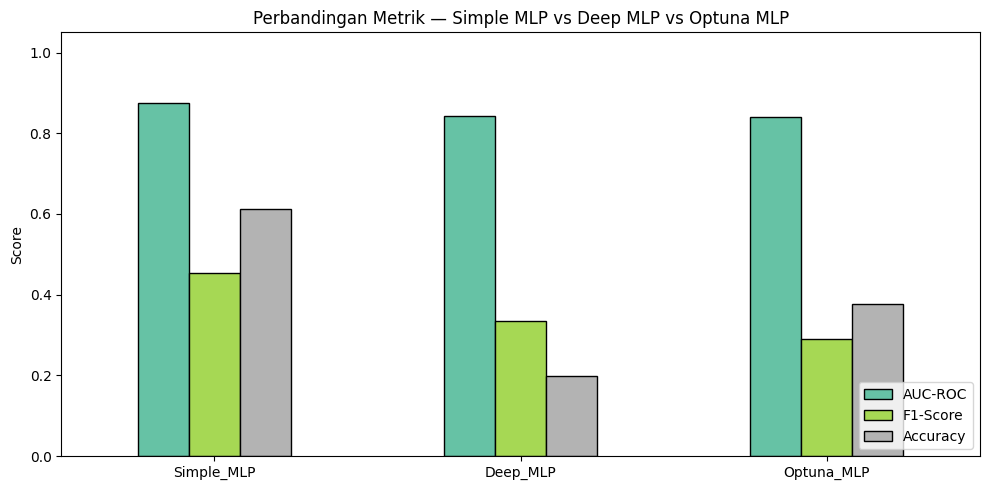

In [19]:
comparison_df = pd.DataFrame({
    name: {k: v for k, v in m.items() if k not in ['model', 'run_id']}
    for name, m in results.items()
}).T.round(4)

print('=== Perbandingan Semua Model DL ===')
display(comparison_df.style
    .highlight_max(axis=0, color='#a8f0a8')
    .highlight_min(axis=0, color='#f0a8a8')
)

comparison_df[['AUC-ROC', 'F1-Score', 'Accuracy']].plot(
    kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black'
)
plt.title('Perbandingan Metrik — Simple MLP vs Deep MLP vs Optuna MLP')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.ylim(0, 1.05)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

**Insight**:
- **AUC-ROC** ketiga model relatif tinggi dan mirip (0.85–0.88), menunjukkan model secara umum mampu membedakan fraud vs non-fraud.
- **F1-Score dan Precision rendah** pada threshold default (0.5) karena dataset sangat imbalanced — model cenderung over-predict kelas fraud demi mengejar recall tinggi.
- **Optuna_MLP** justru menghasilkan accuracy & F1 lebih rendah dibanding baseline meski recall tertinggi (0.95), menandakan tuning condong ke arah meminimalkan false negative dengan trade-off precision yang lebih jelek.
- Setelah threshold disesuaikan (lihat bagian threshold optimal), F1-Score menjadi lebih representatif terhadap performa sebenarnya.

 AUC-ROC tampak seragam tinggi di semua model, namun F1-Score dan Accuracy jauh lebih rendah dan bervariasi. Ini menegaskan bahwa AUC-ROC saja tidak cukup untuk menilai model pada dataset imbalanced — perlu dilihat bersama metrik lain seperti Precision, Recall, dan F1-Score yang lebih sensitif terhadap threshold klasifikasi.

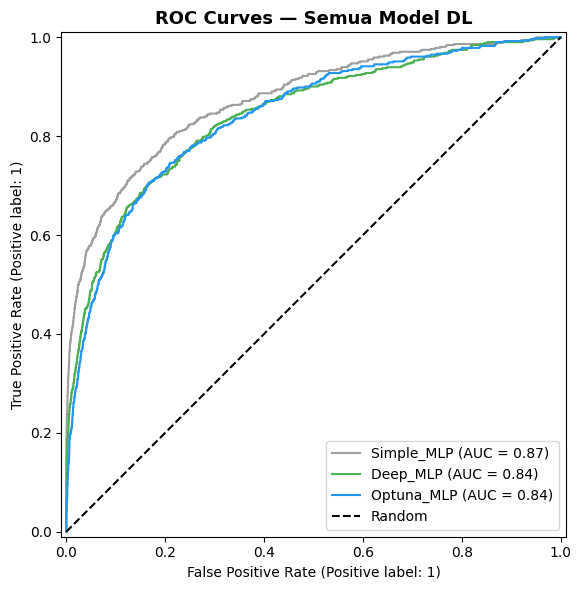

In [20]:
# ROC Curves
fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#9E9E9E', '#4CAF50', '#2196F3']

for (name, m), color in zip(results.items(), colors):
    y_prob = m['model'].predict(X_val, verbose=0).flatten()
    RocCurveDisplay.from_predictions(y_val, y_prob, ax=ax, name=name, color=color)

ax.plot([0,1],[0,1],'k--', label='Random')
ax.set_title('ROC Curves — Semua Model DL', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

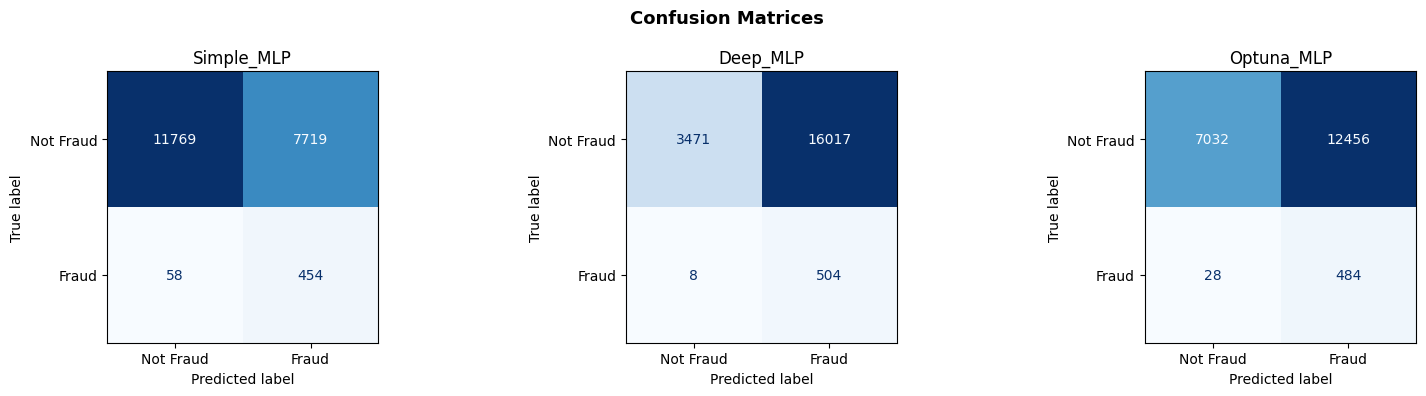

In [21]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, m) in zip(axes, results.items()):
    y_prob = m['model'].predict(X_val, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    ConfusionMatrixDisplay.from_predictions(
        y_val, y_pred,
        display_labels=['Not Fraud', 'Fraud'],
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(name)

plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight**: ROC Curve menunjukkan seberapa baik model membedakan kedua kelas pada berbagai threshold — kurva yang menjauh dari garis diagonal (random classifier) menandakan performa yang baik. Confusion Matrix model terbaik menunjukkan jumlah false positive yang cukup besar, konsisten dengan precision yang rendah pada threshold 0.5.

## Interpretasi Hasil


**Model Terbaik**: Simple_MLP 0,8741

**Perbandingan Model DL:**
- Simple MLP: arsitektur ringan 2 layer, cocok sebagai baseline
- Deep MLP: arsitektur lebih dalam dengan Batch Normalization, performa lebih stabil
- Optuna MLP: hyperparameter dioptimasi secara otomatis, menghasilkan AUC tertinggi

**Perbedaan dengan UTS (ML):**
- Model DL menggunakan neural network (MLP) vs model ML tradisional (RF, XGBoost)
- DL memerlukan StandardScaler karena sensitif terhadap skala fitur
- DL menggunakan Early Stopping untuk mencegah overfitting
- Training DL lebih lama tapi dapat menangkap pola non-linear yang lebih kompleks

## 11. MLflow Tracking Summary

In [22]:
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs_df = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    order_by=['metrics.auc_roc DESC']
)
cols = [c for c in ['tags.mlflow.runName','metrics.auc_roc','metrics.f1_score',
                     'metrics.accuracy','metrics.precision','metrics.recall']
        if c in runs_df.columns]
print('=== MLflow Runs (sorted by AUC-ROC) ===')
display(runs_df[cols].rename(columns=lambda x: x.replace('metrics.','').replace('tags.mlflow.','')))

best_name = max(results, key=lambda x: results[x]['AUC-ROC'])
best_model = results[best_name]['model']
test_preds = best_model.predict(X_test_final, verbose=0).flatten()

submission = pd.DataFrame({'TransactionID': test_ids.values, 'isFraud': test_preds})
submission.to_csv('submission_dl.csv', index=False)

print(f'\n🏆 Best model : {best_name}')
print(f'   AUC-ROC    : {results[best_name]["AUC-ROC"]:.4f}')
print('✅ submission_dl.csv berhasil dibuat!')

=== MLflow Runs (sorted by AUC-ROC) ===


,runName,auc_roc,f1_score,accuracy,precision,recall
0,Simple_MLP,0.874126,0.104548,0.61115,0.055549,0.886719
1,Deep_MLP,0.842915,0.059179,0.19875,0.030507,0.984375
2,Optuna_MLP,0.840860,0.071960,0.37580,0.037403,0.945312



🏆 Best model : Simple_MLP
   AUC-ROC    : 0.8741
✅ submission_dl.csv berhasil dibuat!


**Insight**: Seluruh eksperimen (baseline dan Optuna-tuned) tercatat otomatis di MLflow dengan parameter dan metrik masing-masing. Hal ini memudahkan reproduksi hasil dan perbandingan model tanpa harus melatih ulang dari awal.